# **Asignatura**: Aprendizaje Automático

**Práctica 1**: Aprendizaje supervisado.

**Valoración máxima**: 10 puntos

**Fecha límite de entrega**: Ver PRADO.

**Procedimiento de entrega**: a través de PRADO

### Nombre completo: Jesús Muñoz Velasco



**Normas de desarrollo y entrega de trabajos**

- Única y exclusivamente se debe entregar este Notebook de Colab (fichero `.ipynb`). **No es necesario entregar ninguna memoria externa**.

- El código debe estar bien comentado, y todas las decisiones tomadas y el trabajo desarrollado deben documentarse ampliamente en celdas de texto. **Sin esta documentación, se considera que el trabajo NO ha sido presentado**.

- Se debe respetar la estructura y secciones del Notebook.

- El código **NO debe escribir nada a disco**.

- Una entrega es apta para ser corregida si se puede ejecutar de principio a fin sin errores.


---

# **Ejercicio 1: Problema de Clasificación (5 puntos)**

## 1.1 Contexto: Clasificación de Gama de Móviles

Una empresa de tecnología quiere lanzar un nuevo modelo de teléfono móvil y necesita estimar en qué rango de precios colocarlo para competir en el mercado. Para ello, ha recopilado datos de ventas de diversos móviles con sus especificaciones técnicas.

**Objetivo:** Crear un modelo que clasifique un móvil en uno de los 4 rangos de precios basándose en sus características (RAM, batería, megapíxeles, etc.).

**Variable Objetivo (Target):**
- `price_range`: 0 (Bajo Coste), 1 (Coste Medio), 2 (Coste Alto), 3 (Coste Muy Alto).

**Principales Variables (Features):**
- `battery_power`: Energía total de batería en mAh.
- `ram`: Memoria de acceso aleatorio en Mb (suele ser la más determinante).
- `fc`: Megapíxeles de cámara frontal.
- `int_memory`: Memoria interna en Gb.
- `mobile_wt`: Peso del móvil.
- `touch_screen`: Si tiene pantalla táctil (1) o no (0).
- ... y otras especificaciones de hardware.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carga de datos Clasificación (Mobile Price)
url='https://drive.google.com/file/d/1qciBzxaCwRV-LO-zueyQlBcgxiQtM_eI/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
df_clas = pd.read_csv(url)


print("Datos de Móviles cargados:")
display(df_clas.head())

Datos de Móviles cargados:


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


## 1.2 Análisis Exploratorio de Datos (EDA) y Preprocesado

Realice las siguientes tareas obligatorias:

1.  **Análisis de Variables:** Estudie qué variables tienen mayor correlación con el `price_range`. ¿Es la RAM la más importante? Visualícelo.
2.  **Valores Nulos y Outliers:** Compruebe la limpieza del dataset.
3.  **Escalado de Datos:** Dado que tenemos variables con rangos muy distintos (ej: `battery_power` en miles vs `clock_speed` decimal), es **obligatorio** escalar las características (StandardScaler/MinMaxScaler).
4.  **Selección de Características:** (Opcional) Puede intentar reducir la dimensionalidad o eliminar variables con baja correlación (ej. `three_g` o `touch_screen` si no afectan al precio).

### 1.2.1. Análisis de Variables

Comenzamos formateando los datos especificando cuál es la columna objetivo y vemos una descripción inicial del conjunto de datos

In [2]:
# Extraemos las características (X) y las etiquetas (y)
X_raw = df_clas[df_clas.columns[:-1]].values
Y_raw = df_clas['price_range'].values

print("Dimensiones de X: {} datos y {} atributos/dato".format(X_raw.shape[0], X_raw.shape[1]))

etiquetas= np.unique(Y_raw)

print("Hay {} etiquetas distintas: {}".format(len(etiquetas), etiquetas))

print('\nInformación básica del dataset: ')
df_clas.info()


Dimensiones de X: 2000 datos y 20 atributos/dato
Hay 4 etiquetas distintas: [0 1 2 3]

Información básica del dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 

Continuamos calculando la correlación de cada variable

In [3]:
# Calculamos la correlación de todas las variables con la columna objetivo
correlaciones = df_clas.corr()['price_range'].sort_values(ascending=False)

print("Correlación de cada variable con el rango de precios:")
print(correlaciones)

Correlación de cada variable con el rango de precios:
price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64


En la salida anterior podemos ver que efectivamente la variable más representativa con mucha diferencia es la `ram`. Las siguientes más representativas (en orden descendente) son:
- `battery_power`
- `px_width`
- `px_height`

y el resto son bastante poco representativas.

### 1.2.2. Valores nulos y outliers

Previamente, en la descripción inicial del dataset vimos que no había valores nulos. Para ver si hay outliers podemos representar cada variable con un gráfico de cajas y bigotes (además de estudiar estadísticos básicos como la desviación típica que también nos dará un factor de dispersión). Para visualizar mejor este gráfico haremos un escalado previo con `MinMaxScaler`.

In [4]:
print('Estadísticos básicos: ')
df_clas.describe()

Estadísticos básicos: 


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


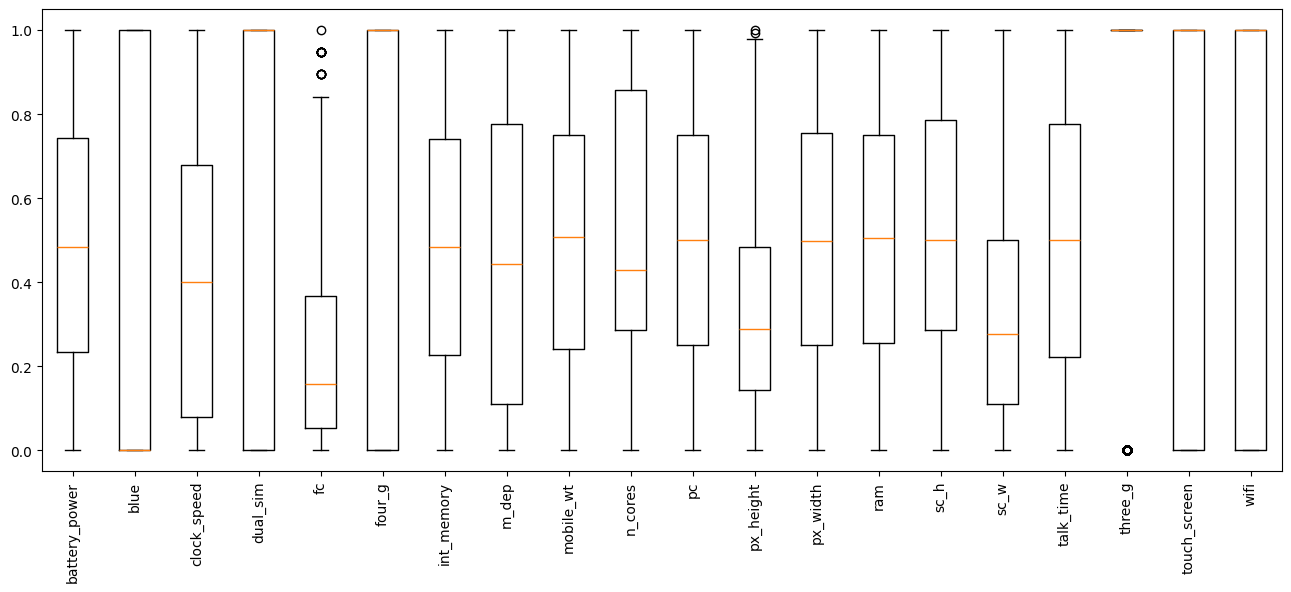

In [5]:
from sklearn.preprocessing import MinMaxScaler

# Escalamos los datos
mme= MinMaxScaler(feature_range=(0,1))

X_norm = mme.fit_transform(X_raw)

# Representamos el gráfico de cajas y bigotes
plt.figure(figsize=(16, 6))
plt.boxplot(X_norm, tick_labels=df_clas.columns[:-1])
plt.xticks(rotation=90)
plt.show()

Con este gráfico se ve que hay outliers en las siguientes columnas:
- `fc`
- `three_g`
- `px_height`

como estas características son poco representativas (como se ha visto al calcular el índice de correlación) excepto `px_height` nos plantearemos solo arreglar esta característica.

Sin embargo planteamos ahora la extracción de una nueva característica, los `ppi` (píxeles por pulgada), que se calculan de acuerdo a la siguiente fórmula:
$$PPI = \frac{\sqrt{px_h^2 + px_w^2}}{d}$$
donde $d$ es el tamaño diagonal de la pantalla, que se calcula como:
$$ d = \sqrt{sc_h^2 + sc_w^2} $$
Como no nos interesa el factor de escalado simplemente calcularemos la densidad de pixeles con las unidades del dataset para luego reescalarlas como antes. Estudiaremos si la correlación de esta nueva característica y el `price_range` es significativa.


In [6]:
d = np.sqrt(df_clas['sc_h']**2 + df_clas['sc_w']**2)

# Calculamos el PPI
ppi = np.sqrt(df_clas['px_width']**2 + df_clas['px_height']**2) / d

# Calculamos la correlación de esta nueva columna
correlacion = ppi.corr(df_clas['price_range'])
print(f"La correlación entre el PPI y el Precio es: {correlacion:.4f}")

La correlación entre el PPI y el Precio es: 0.0812


Vemos que no es muy alto y descartamos esta idea. Nos planteamos qué hubiera pasado si hubiésemos tenido solo en cuenta la diagonal en píxeles (ya que tanto `px_width` como `px_height` eran bastante representativos).

In [7]:
# Calculamos los pixeles diagonales
px_d = np.sqrt(df_clas['px_width']**2 + df_clas['px_height']**2)

# Calculamos la correlación de esta nueva columna
correlacion = px_d.corr(df_clas['price_range'])
print(f"La correlación entre la diagonal en píxeles y el precio es: {correlacion:.4f}")

La correlación entre la diagonal en píxeles y el precio es: 0.1804


y vemos que hemos mejorado bastante con respecto a los `ppi` y es incluso más alto que cualquiera de las medidas en píxeles de la pantalla. La escalamos y podemos proceder a la extracción de características.

In [8]:
px_d_scaled = mme.fit_transform(px_d.values.reshape(-1, 1))

# La añadimos a X_norm
X_norm = np.hstack((X_norm, px_d_scaled))

Veamos qué sucedería con una extracción PCA

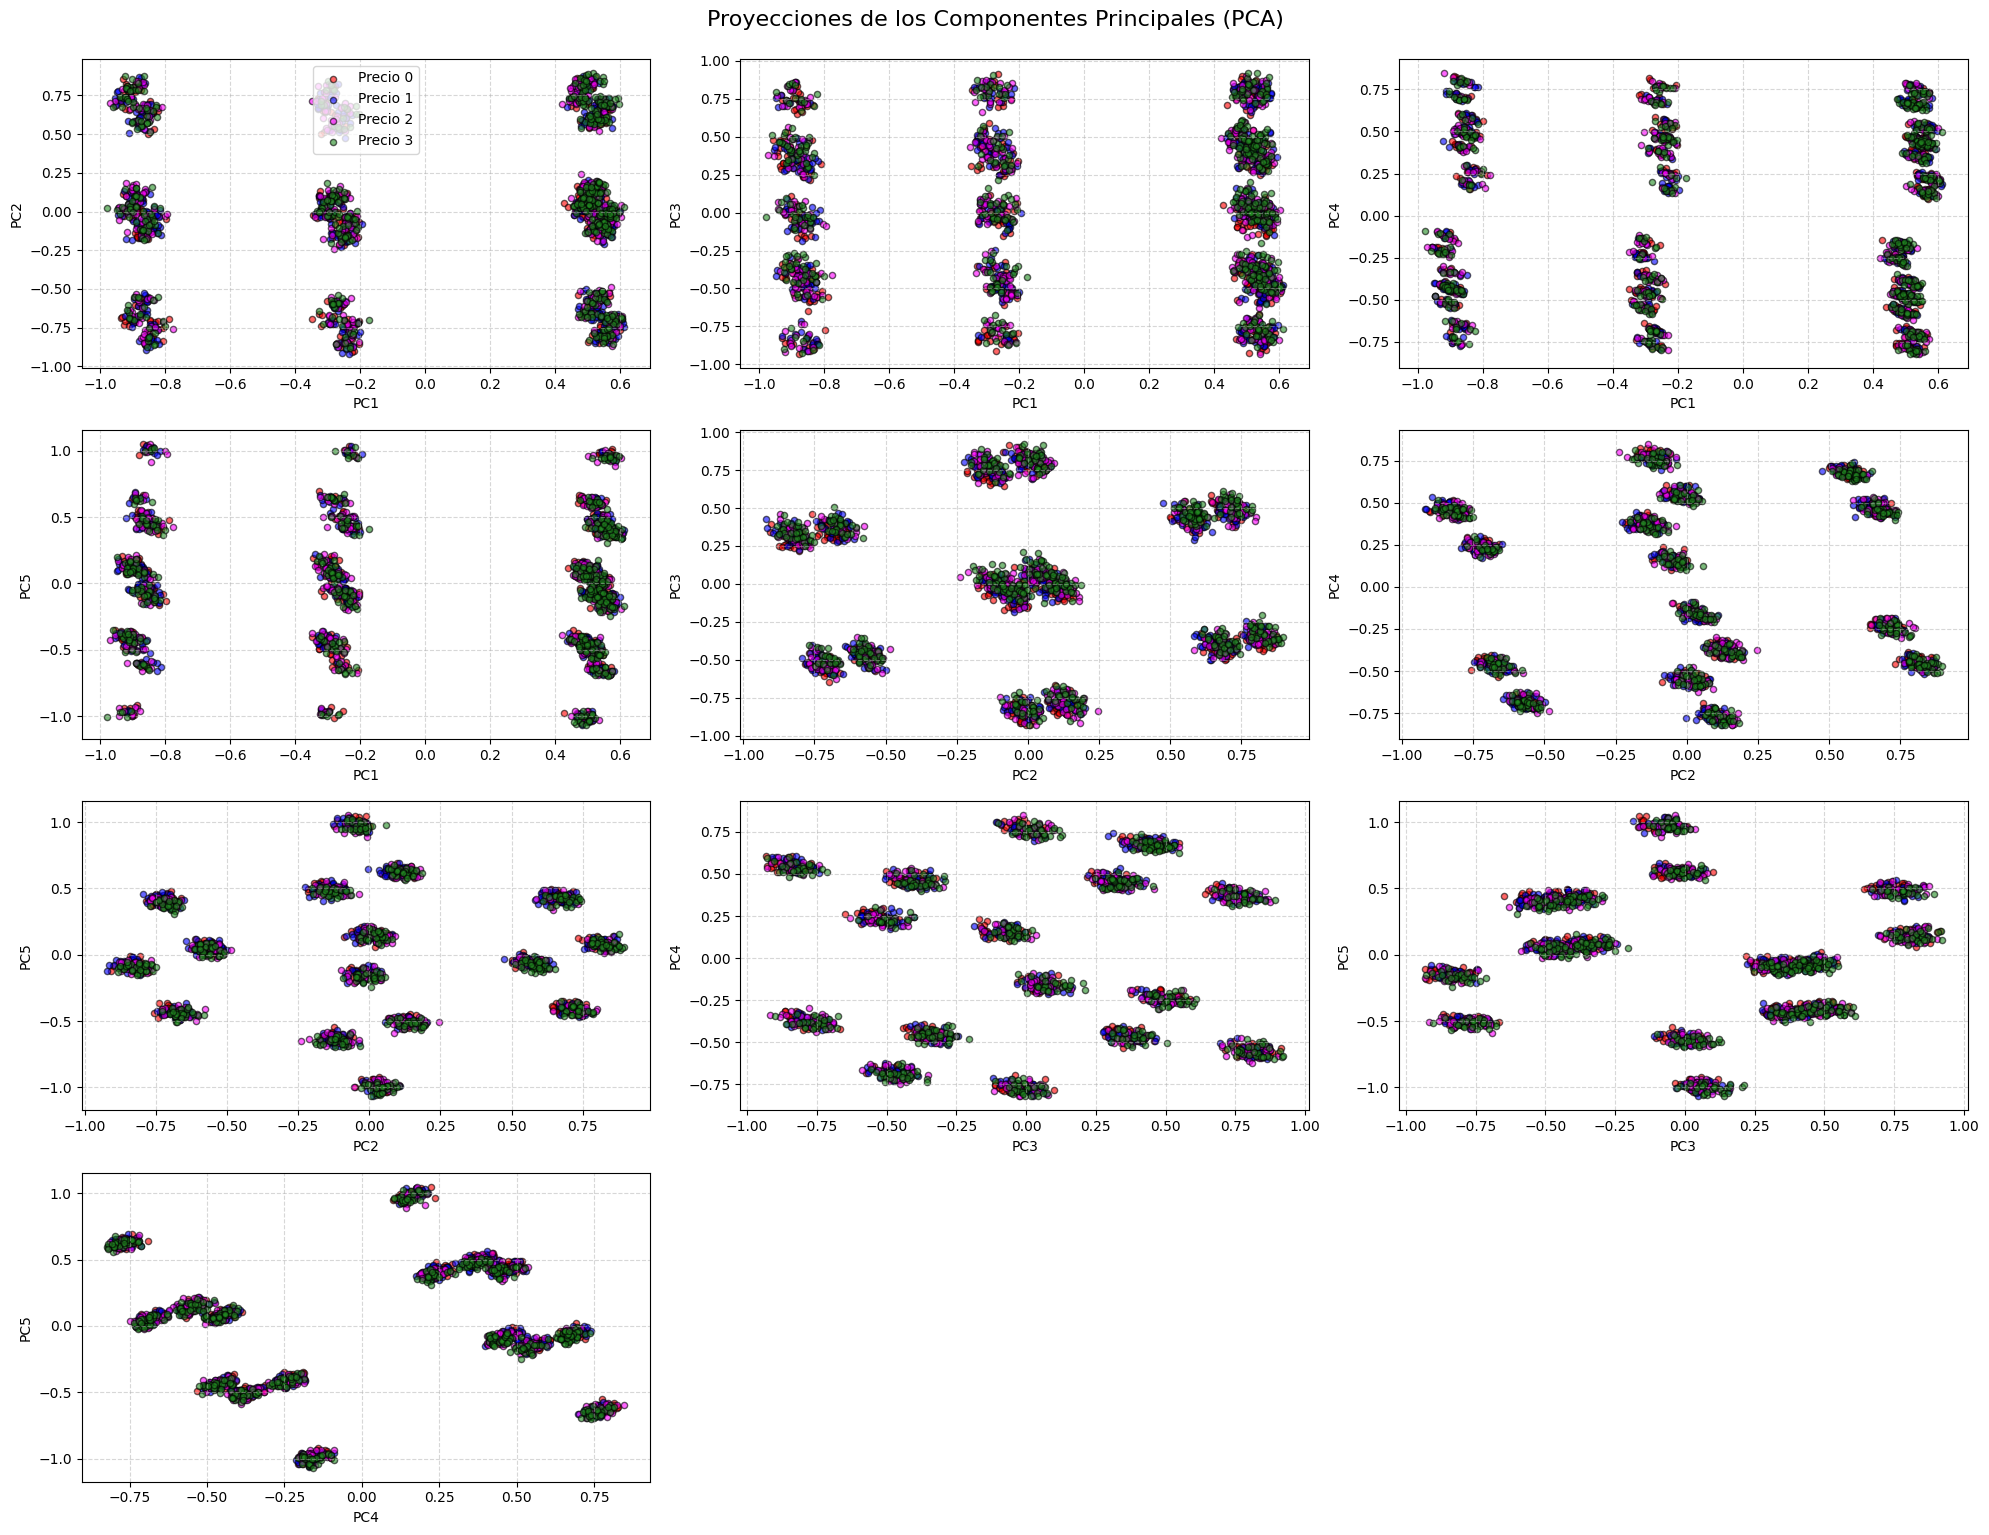

In [9]:
from sklearn.decomposition import PCA

# Hacemos la extracción de características para 5 columnas
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_norm)

# Creamos un DataFrame con los componentes y la etiqueta de precio
nombres_pca = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=nombres_pca)
df_pca['price_range'] = Y_raw # Añadimos la etiqueta original

# Dibujamos las gráficas
from itertools import combinations

# Definimos los rangos de precios
rangos = np.unique(Y_raw)
colores = ['red', 'blue', 'magenta', 'forestgreen']

columnas_pca = df_pca.columns[:-1]  # 'PC1' hasta 'PC5'
n_componentes = len(columnas_pca)
combinaciones = list(combinations(range(n_componentes), 2))

# Combinaciones de todas con todas las columnas (sin permutar)
plt.figure(figsize=(20, 15)) # Aumentamos el tamaño para que se vea claro

for i, (idx1, idx2) in enumerate(combinaciones, 1):
    plt.subplot(4, 3, i)

    for rango, color in zip(rangos, colores):
        # Filtramos las filas que pertenecen a cada rango de precio
        mask = (Y_raw == rango)
        plt.scatter(X_pca[mask, idx1], X_pca[mask, idx2],
                    label=f'Precio {rango}', color=color,
                    alpha=0.6, edgecolors='k', s=20)

    plt.xlabel(columnas_pca[idx1])
    plt.ylabel(columnas_pca[idx2])
    if i == 1: plt.legend() # Solo ponemos la leyenda en el primer gráfico para no saturar
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout() # Ajusta automáticamente los espacios entre gráficas
plt.suptitle("Proyecciones de los Componentes Principales (PCA)", fontsize=16, y=1.02)
plt.show()


Llegamos a la conclusión de que esta no parece la mejor técnica (no se ve una distinición medianamente clara en las clases). Se ha probado con distinto número de componentes pero no se ha llegado a un resultado satisfactorio.

Vamos ahora a probar a extraer características manualmente y después de este estudio previo llegamos a que las mejores características a considerar para nuestro modelo serán:
- `ram`
- `battery_power`
- `px_d`

Podríamos considerar alguna más pero yo en este caso lo voy a evitar para reducir el ruido (excepto que no dé resultados satisfactorios)

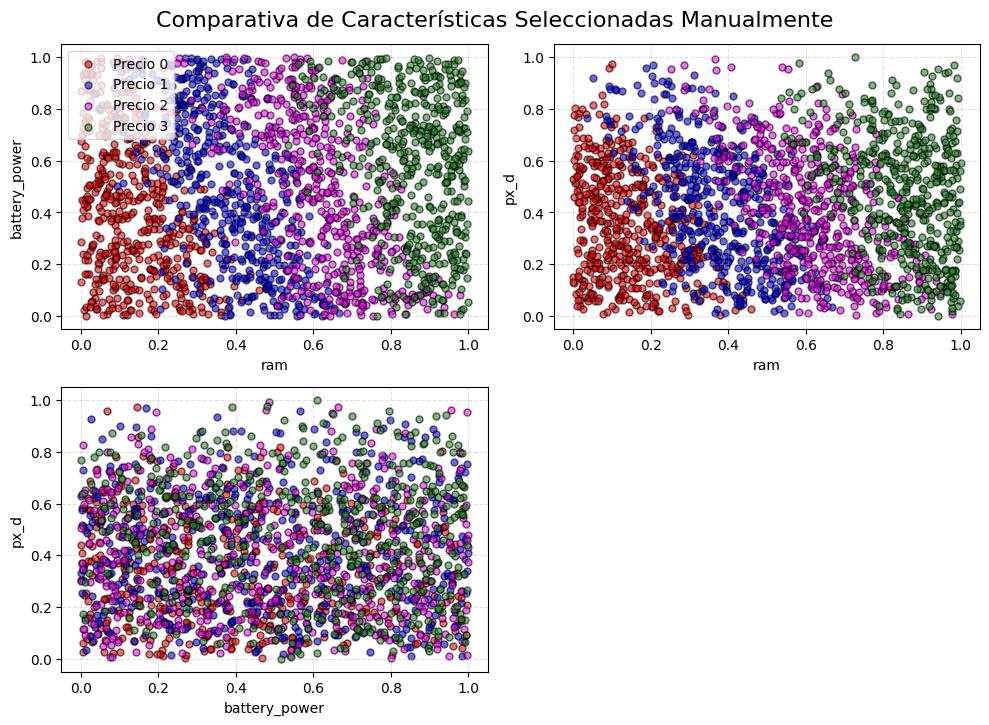

In [10]:
# Reconstruimos el DataFrame escalado para poder usar nombres de columnas
nombre_cols = list(df_clas.columns[:-1]) + ['px_d'] # Si añadiste px_d al final
df_norm = pd.DataFrame(X_norm, columns=nombre_cols)

# Elegimos las columnas más representativas
mis_columnas = ['ram', 'battery_power', 'px_d']

# Extraemos los datos
X_seleccionado = df_norm[mis_columnas].values
nombres_cols = mis_columnas

# Definiciones básicas
rangos = np.unique(Y_raw)
colores = ['red', 'blue', 'magenta', 'forestgreen']
n_cols = len(nombres_cols)
combinaciones = list(combinations(range(n_cols), 2))

# Configuramos el lienzo (ajusta el grid según el número de combinaciones)
# Para 5 columnas hay 10 combinaciones -> 2 filas x 5 columnas
plt.figure(figsize=(10, 10))

for i, (idx1, idx2) in enumerate(combinaciones, 1):
    plt.subplot(3, 2, i)

    for rango, color in zip(rangos, colores):
        mask = (Y_raw == rango)
        # Usamos X_seleccionado que contiene solo tus columnas elegidas
        plt.scatter(X_seleccionado[mask, idx1], X_seleccionado[mask, idx2],
                    label=f'Precio {rango}', color=color,
                    alpha=0.6, edgecolors='k', s=25)

    plt.xlabel(nombres_cols[idx1])
    plt.ylabel(nombres_cols[idx2])
    if i == 1: plt.legend()
    plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.suptitle("Comparativa de Características Seleccionadas Manualmente", fontsize=16, y=1.02)
plt.show()

Vemos mucho más claramente la diferencia de rangos cuando entra la ram en juego. Sin embargo vemos que las otras 2 características combinadas no aportan mucha información. Vamos a intentar combinarlas con una regla parecida para ver si podemos tener las clases un poco más separadas.

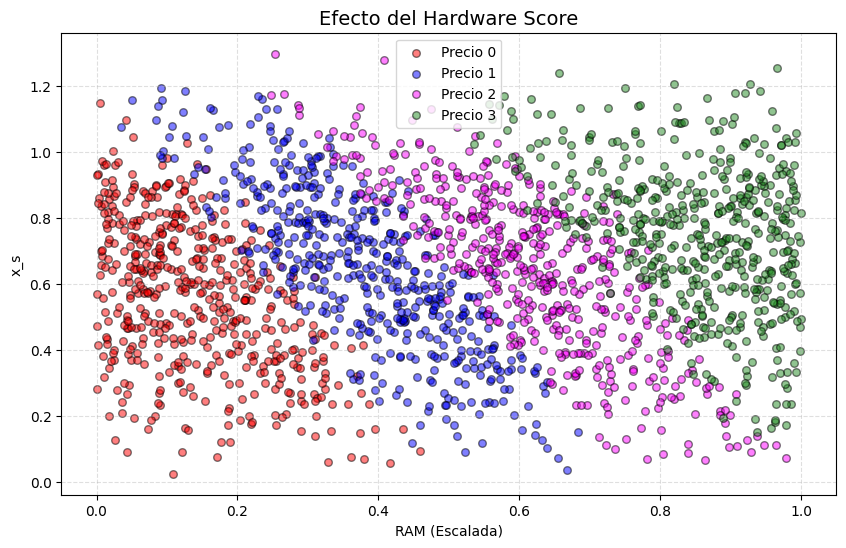

Correlación del x_s con el rango de precio: 0.2707


In [11]:
# Calculamos la nueva característica
df_norm['x_s'] = np.sqrt(0.78*(df_norm['battery_power']**2) + (df_norm['px_d']**2))

# Visualizamos esta nueva métrica
plt.figure(figsize=(10, 6))

for rango, color in zip(rangos, colores):
    mask = (Y_raw == rango)
    plt.scatter(df_norm.loc[mask, 'ram'],
                df_norm.loc[mask, 'x_s'],
                label=f'Precio {rango}',
                color=color, alpha=0.5, edgecolors='k', s=30)

plt.title("Efecto de x_s", fontsize=14)
plt.xlabel("RAM (Escalada)")
plt.ylabel("x_s")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# Comprobamos la correlación de esta nueva característica
corr_score = df_norm['x_s'].corr(pd.Series(Y_raw))
print(f"Correlación del x_s con el rango de precio: {corr_score:.4f}")

Vemos ya una diferencia mucho más clara entre los diferentes rangos. Vamos a entrenar nuestro modelo de acuerdo a estas características

## 1.3 Entrenamiento y Validación (Clasificación Multiclase)

Pruebe al menos 2 modelos de clasificación (ej. KNN, Random Forest, SVM con kernel RBF). (no escoger dos del mismo tipo)

- **Nota Importante:** Al ser un problema **multiclase** (4 clases), asegúrese de configurar las métricas adecuadamente (ej. `average='macro'` o `'weighted'`).
- **Métricas obligatorias:** Accuracy, Informe de Clasificación (Precision/Recall/F1 por clase) y Matriz de Confusión (Heatmap).


==================== Random Forest ====================
Precisión final en el conjunto de prueba: 92.50%



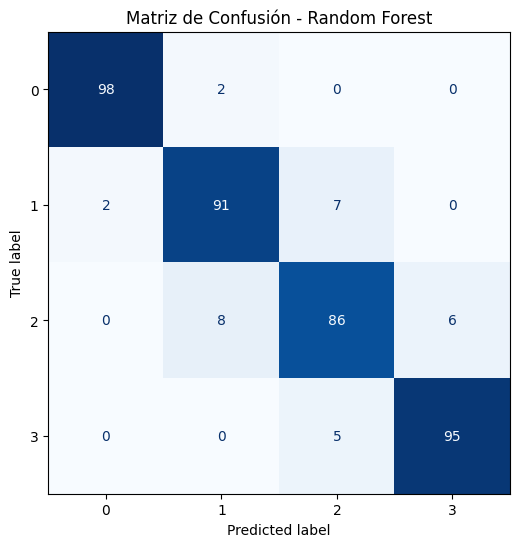

Report de Random Forest:


,precision,recall,f1-score,support
Precio 0,0.9800,0.980,0.9800,100.000
Precio 1,0.9010,0.910,0.9055,100.000
Precio 2,0.8776,0.860,0.8687,100.000
Precio 3,0.9406,0.950,0.9453,100.000
accuracy,0.9250,0.925,0.9250,0.925
macro avg,0.9248,0.925,0.9249,400.000
weighted avg,0.9248,0.925,0.9249,400.000


------------------------------------------------------------

==================== SVM (Kernel RBF) ====================
Precisión final en el conjunto de prueba: 86.25%



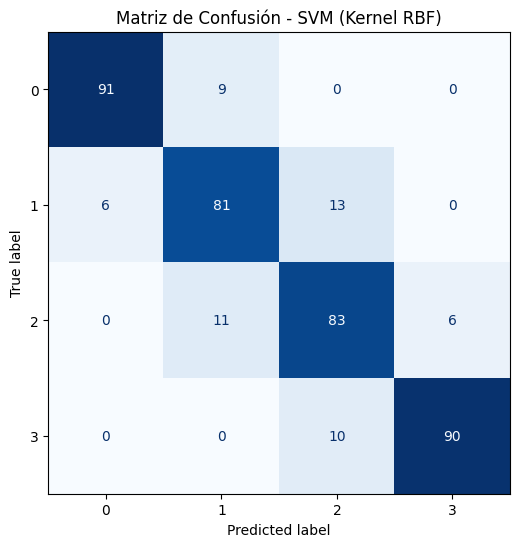

Report de SVM (Kernel RBF):


,precision,recall,f1-score,support
Precio 0,0.9381,0.9100,0.9239,100.0000
Precio 1,0.8020,0.8100,0.8060,100.0000
Precio 2,0.7830,0.8300,0.8058,100.0000
Precio 3,0.9375,0.9000,0.9184,100.0000
accuracy,0.8625,0.8625,0.8625,0.8625
macro avg,0.8652,0.8625,0.8635,400.0000
weighted avg,0.8652,0.8625,0.8635,400.0000


------------------------------------------------------------


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.svm import SVC

# Preparamos los datos
X = df_norm.values
y = Y_raw
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Definimos los modelos a comparar
modelos = {
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42),
    "SVM (Kernel RBF)": SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
}

for nombre, mod in modelos.items():
    # Entrenamiento
    mod.fit(X_train, y_train)

    # Predicción
    y_pred = mod.predict(X_test)

    # Validación
    print(f"\n{'='*20} {nombre} {'='*20}")
    precision_final = accuracy_score(y_test, y_pred)
    print(f"Precisión final en el conjunto de prueba: {precision_final * 100:.2f}%\n")

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3])

    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    plt.title(f'Matriz de Confusión - {nombre}')
    plt.show()

    # Classification report
    report_dict = classification_report(y_test, y_pred,
                                        target_names=[f'Precio {i}' for i in range(4)],
                                        output_dict=True)

    print(f'Report de {nombre}:')
    df_report = pd.DataFrame(report_dict).transpose()
    display(df_report.round(4))
    print("-" * 60)

## **Conclusiones Generales**

Añada una celda de texto final comparando los resultados obtenidos con los diferentes modelos, y extraiga conclusiones sobre si hay alguno mejor que otro en función del número de parámetros requerido, la precisión, etc.

Tras todo este estudio podemos ver que Random Forest es un poco superior a SVM con un 92.5% de acierto medio, en especial en la frontera entre los rangos 1 y 2, donde el SVM ha fallado más (casi el doble).

Podemos ver que la extracción de características ha sido también muy satisfactoria ya que, independientemente del modelo elegido, el nivel de acierto es muy alto en ambos casos. Esto además indica que es muy importante entender los datos con los que se están trabajando (el nivel de correlación de las características con el objetivo y las combinaciones entre ellas).

Como conclusión final, la empresa debería de usar este modelo **Random Forest** ya que asegura que la empresea no infravalore un móvil de gama alta ni sobrevalore uno de gama media, optimizando bastante bien los precios para el mercado.

Además, el estudio nos indica que se podrían abaratar costes en componentes que no se valoran mucho por parte de la clientela como puede ser el tener o no pantalla táctil (lo veíamos en el estudio de la correlación).

---

# **Ejercicio 2: Problema de Regresión (5 puntos)**

## 2.1 Contexto: Predicción de la Resistencia del Hormigón

En ingeniería civil, la resistencia a la compresión del hormigón es una función compleja de su edad y sus ingredientes. En este ejercicio, deberá desarrollar un modelo de regresión para **predecir la resistencia (en MegaPascales, MPa)** basándose en la composición de la mezcla.

**Dataset:** Concrete Compressive Strength Data Set (UCI Machine Learning Repository).

- **Variables de Entrada (X):** Cemento, Escoria, Ceniza, Agua, Superplastificante, Árido grueso, Árido fino, Edad (días).
- **Variable de Salida (Y):** Resistencia a la compresión del hormigón (MPa).


In [13]:
# Carga de datos Regresión
url= 'https://drive.google.com/file/d/1mlzSDAUlXMMTjL7PbpXJQddHKAyZeYft/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]

df_reg = pd.read_csv(url)

print("Datos de Regresión cargados:")
display(df_reg.head())

Datos de Regresión cargados:


,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


## 2.2 Análisis y Preprocesado (Regresión)

Prepare los datos para el modelado:
1.  Estudie la distribución de la variable objetivo (`strength`).
2.  Analice la correlación de las variables de entrada con la salida.
3.  Aplique el escalado necesario a las variables independientes.

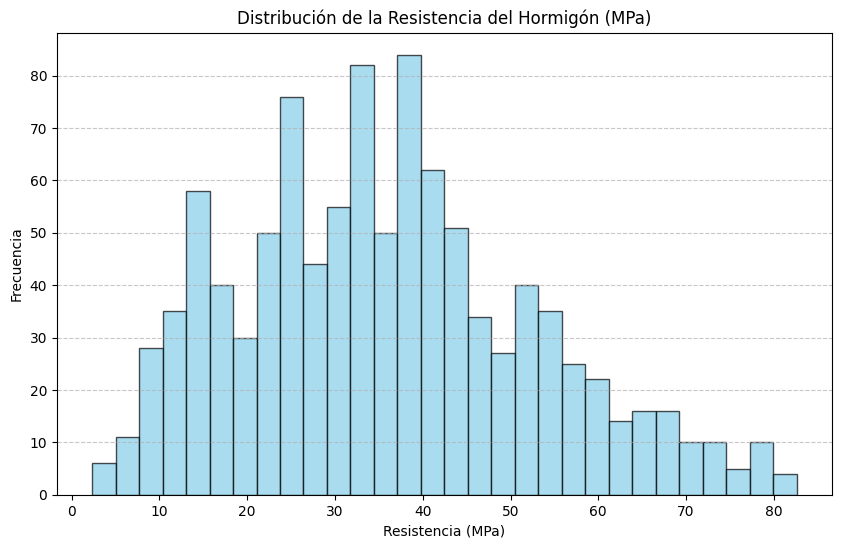

Estadísticas descriptivas de strength:
count    1030.000000
mean       35.817961
std        16.705742
min         2.330000
25%        23.710000
50%        34.445000
75%        46.135000
max        82.600000
Name: strength, dtype: float64


In [14]:
from sklearn.preprocessing import StandardScaler

# Estudio de la distribución de la variable objetivo (strength)
objetivo = 'strength'

plt.figure(figsize=(10, 6))
plt.hist(df_reg[objetivo], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribución de la Resistencia del Hormigón (MPa)')
plt.xlabel('Resistencia (MPa)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Estadísticas descriptivas de {objetivo}:")
print(df_reg[objetivo].describe())

Podemos ver que la distribución se asemeja a una campana de Gauss por lo que ajustaremos los datos a una distribución normal.

In [15]:
# Análisis de la correlación de las variables de entrada con la salida
correlaciones = df_reg.corr()[objetivo].sort_values(ascending=False)

print("\nCorrelación de las variables con la Resistencia:")
print(correlaciones)


Correlación de las variables con la Resistencia:
strength        1.000000
cement          0.497832
superplastic    0.366079
age             0.328873
slag            0.134829
ash            -0.105755
coarseagg      -0.164935
fineagg        -0.167241
water          -0.289633
Name: strength, dtype: float64


Vemos que en el problema actual no hay ninguna característica que destaque muy por encima del resto. Sin embargo, las más representativas son:
- `cement`
- `superplastic`
- `age`
- `water` (correlación inversa)

In [16]:
# Escalado de las variables independientes
X = df_reg.drop(columns=[objetivo])
y = df_reg[objetivo]

# Elegimos StandardScaler
scaler = StandardScaler()

# Ajustamos y transformamos los datos de entrada
X_scaled = scaler.fit_transform(X)

# Convertimos de nuevo a DataFrame para facilitar su uso posterior
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\nVariables independientes escaladas:")
display(X_scaled_df.head())


Variables independientes escaladas:


,cement,slag,ash,water,superplastic,coarseagg,fineagg,age
0,2.477915,-0.856888,-0.847144,-0.916764,-0.620448,0.863154,-1.217670,-0.279733
1,2.477915,-0.856888,-0.847144,-0.916764,-0.620448,1.056164,-1.217670,-0.279733
2,0.491425,0.795526,-0.847144,2.175461,-1.039143,-0.526517,-2.240917,3.553066
3,0.491425,0.795526,-0.847144,2.175461,-1.039143,-0.526517,-2.240917,5.057677
4,-0.790459,0.678408,-0.847144,0.488793,-1.039143,0.070527,0.647884,4.978487


## 2.3 Modelado y Evaluación (Regresión)

Entrene al menos 2 modelos de regresión (ej. Regresión Lineal, SVR, Gradient Boosting...).

**Métricas obligatorias:**
- MSE (Mean Squared Error)
- R2 Score (Coeficiente de determinación)
- MAE (Mean Absolute Error)

Incluya una gráfica de dispersión: Valores Reales (eje X) vs Valores Predichos (eje Y).

--- Regresión Lineal ---
MSE: 95.9709
R2 Score: 0.6276
MAE: 7.7456

--- Random Forest ---
MSE: 29.9422
R2 Score: 0.8838
MAE: 3.7385



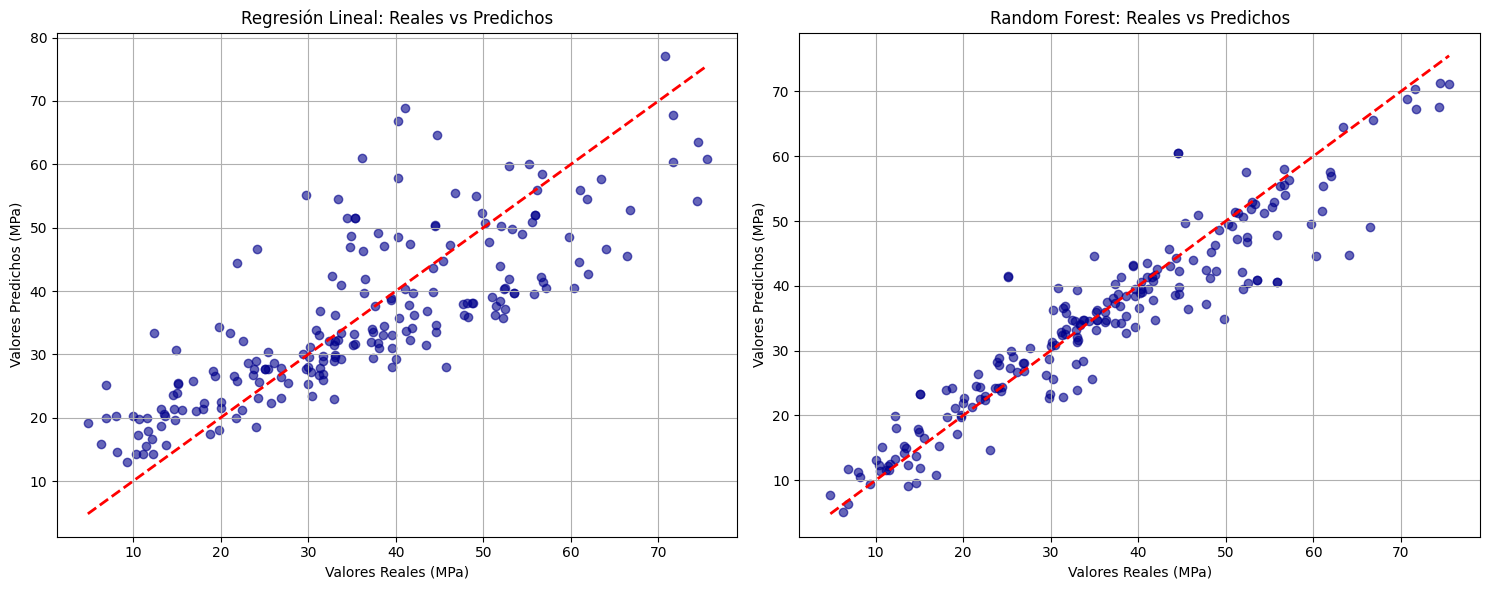

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# División de los datos en entrenamiento y prueba (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Definición de modelos
models = {
    "Regresión Lineal": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# Diccionario para almacenar resultados
results = {}

# Entrenamiento y Evaluación
for name, model in models.items():
    # Entrenar
    model.fit(X_train, y_train)
    # Predecir
    y_pred = model.predict(X_test)

    # Calcular métricas
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results[name] = {'MSE': mse, 'R2': r2, 'MAE': mae, 'preds': y_pred}

    print(f"--- {name} ---")
    print(f"MSE: {mse:.4f}")
    print(f"R2 Score: {r2:.4f}")
    print(f"MAE: {mae:.4f}\n")

# Gráfica de dispersión
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, (name, metrics) in enumerate(results.items()):
    axes[i].scatter(y_test, metrics['preds'], alpha=0.6, color='darkblue')
    # Línea de referencia para predicción perfecta
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[i].set_title(f'{name}: Reales vs Predichos')
    axes[i].set_xlabel('Valores Reales (MPa)')
    axes[i].set_ylabel('Valores Predichos (MPa)')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

## **Conclusiones Generales**

Añada una celda de texto final comparando los resultados obtenidos con los diferentes modelos, y extraiga conclusiones sobre si hay alguno mejor que otro en función del número de parámetros requerido, la precisión, etc.

Podemos ver fácilmente en las gráficas a primera vista que el Random Forest es más preciso (se visualiza menos dispersión).

Además, en términos numéricos tenemos que el modelo de Regresión Lineal explica el $62.7\%$ de la variabilidad de la resistencia frente al 88.3% que explica el modelo Random Forest.

El MAE nos confirma lo que se veía a primera vista y es que el modelo lineal tiene un error promedio de 7.75 MPa, más del doble que el Random Forest.

Finalmente, en cuanto al Error Cuadrático Medio vemos también que el Random Forest tiene un factor muchísimo más bajo lo que lo hace tener menos valores Outliers.

Por tanto, a todos los efectos, el modelo Random Forest es mucho mejor que el modelo de regresión lineal.

---